In [1]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import plot_utils as pu

In [2]:
# configure the backend for matplotlib
# this one should allow zoom:
# %matplotlib widget
# to make that work you need: "pip install ipympl" and run "jupyter nbextension enable --py widgetsnbextension"

# this will work without the above dependencies but won't allow zoom
%matplotlib inline

# this option may work whenever they fix bugs in mpld3
# import mpld3
# mpld3.enable_notebook()

Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Running model: 2D from bottom (steep, y<=2)
Set parameter LogToConsole to value 0
   Relaxed 2 variables on 2D from bottom (steep, y<=

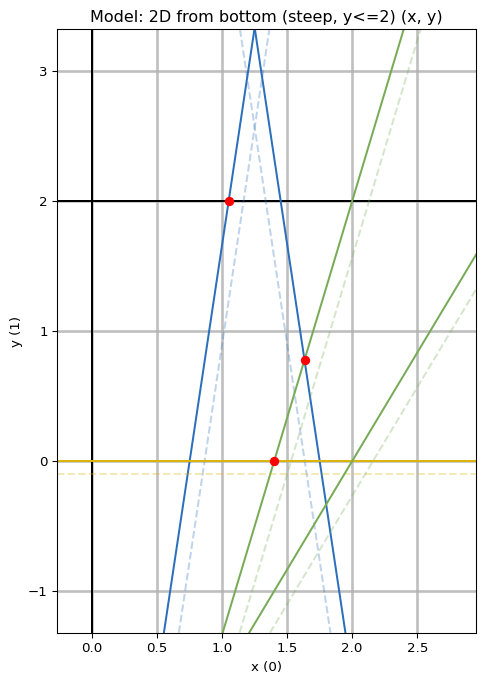

In [ ]:
def find_unimodular(tableau, row):
    n = tableau.shape[1]
    result = np.zeros((n, n))
    for i in range(n):
        result[i, i] = 1 if tableau[row, i] >= 0 else -1
    return result

# A function to create cuts given a target point
def add_cut(relaxed: gp.Model, integer_vars, integer_idx, plotter):
    
    if plotter is not None:
        plotter.add_ball(1.2)

    tol = relaxed.params.FeasibilityTol
    all_done = True
    for iv in integer_vars:
        x = iv.X.item()
        if not np.isclose(x, round(x), atol=tol):
            all_done = False
            break
    if all_done:
        return False
    
    variables = relaxed.getVars()  # TODO: pass this in as it's expensive?
    constraints = relaxed.getConstrs()  # wish we didn't have to use this one
    
    def find_variable_value(index):
        if index < len(variables):
            if variables[index].VBasis == -2:
                raise NotImplementedError("handle vbasis")  # not yet sure what to do here
            return variables[index].X
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        try:
            return constraint.Slack
        except:
            return 0.0
    
    def find_variable(index):
        if index < len(variables):
            # handle inverted variables (SCIP and Gurobi both have this silliness)
            match variables[index].VBasis:
                case -3:
                    raise NotImplementedError("Not yet handling VBasis == -3") 
                case -2:
                    return variables[index].UB - variables[index]
                case -1:
                    return variables[index] - variables[index].LB
                case _:
                    return variables[index]
        # if only gurobi gave us access to their slack variables...
        # instead, we have to solve for it:
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        lhs, sense, rhs = relaxed.getRow(constraint), constraint.Sense, constraint.RHS
        if sense == '<':
             return rhs - lhs
        elif sense == '>':
            return lhs - rhs
        else:
            return 0.0  # Gurobi has slacks on equality constraints, but they must always be 0
    
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=0)
    negated_vars = [basis[nr] for nr in negated_rows]
    
    # drop the rows of non-integer variables:
    to_drop = [i for i, b in enumerate(basis) if b not in integer_idx]
    tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    basis = np.delete(basis, to_drop)

    # drop all rows that are non-fractional:
    tol = relaxed.params.IntFeasTol
    # to_drop = [i for i, b in enumerate(basis) if np.isclose(x[integer_idx[b]], round(x[integer_idx[b]]), tol)]
    # tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    # basis = np.delete(basis, to_drop)
    # x_idx = [integer_idx[b] for b in basis]

    # the current understanding (from nlhdlr_quadratic.c in SCIP): 
    # negate all columns with variables at status -1
    # and negate all columns match slack variables of type <
    for row, j in enumerate(col_to_var_idx):
        if j < len(variables):
            if variables[j].VBasis == -1:  # not sure what to do with VBasis=-3
                tableau[:, row] = -tableau[:, row]
        else:
            constraint = constraints[j - len(variables)]
            # this might not be right: scip has status and tests for A_i*x being at lower or upper bound
            if constraint.Sense != '>':  # still unsure on this one; can't tell what to do with equality 
                tableau[:, row] = -tableau[:, row]

    # check for rows we can handle before the transform:
    # pos_rows = [i for i, t in enumerate(transformed) if np.all(t >= -tol)]
    # neg_rows = [i for i, t in enumerate(transformed) if np.all(t <= tol)]

    to_cut = [(i, b, find_variable_value(b)) for i, b in enumerate(basis)  # can't call find_var_value after addConstr or update
            if b in integer_idx and tol < (integer_vars[integer_idx[b]].X % 1) < 1.0-tol]
    
    cuts = []
    for row, base, x in to_cut:
        if np.all(np.isclose(tableau[row], 0.0, atol=tol)):
            print("Warning! Empty row", row)
            continue
        elif np.all(tableau[row] >= 0 - tol):
            cuts.append(find_variable(base) >= np.ceil(x))
        elif np.all(tableau[row] <= 0 + tol):
            cuts.append(find_variable(base) <= np.floor(x))
            
    if len(cuts) > 0:
        print("Added simple bound cuts:", len(cuts))
        for cut in cuts: 
            bc = relaxed.addConstr(cut)
            if plotter is not None:
                relaxed.update()
                plotter.add_constraint(bc)
        return True

    col_vars = [find_variable(c) for c in col_to_var_idx]
    u: np.ndarray = find_unimodular(tableau, to_cut[0][0])
    tableau2 = tableau @ u
    for row, base, x in to_cut:
        if np.all(np.isclose(tableau2[row], 0.0, atol=tol)):
            print("Warning! Empty row", row)
            continue  # TODO: I don't really want this to be possible
        elif np.all(tableau2[row] >= 0 - tol):
            cuts.append((tableau2[row] @ col_vars >= np.ceil(x) - x, 'xkcd:asparagus'))
        elif np.all(tableau2[row] <= 0 + tol):
            cuts.append((tableau2[row] @ col_vars <= np.floor(x) - x, 'xkcd:berry'))

    if len(cuts) > 0:
        print("Added simple bound cuts after transform:", len(cuts))
        for cut, color in cuts: 
            bc = relaxed.addConstr(cut)
            if plotter is not None:
                relaxed.update()
                plotter.add_constraint(bc, color)
        return True

    return False

def run_cuts_to_relaxed_sol(instances, loops=8, graph_2D_3D=True):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        model.update()
        plotter = pu.create(model) if graph_2D_3D else None

        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break

            print("   Loop:", i+1, ", Relaxed score:", model.getObjective().getValue())
            if not add_cut(model, int_vars, int_idx, plotter):
                print("   Done! All constraints met.")
                break

        print("   Known best score:", instance.score if instance.known_optimum else "unknown")    
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples:
run_cuts_to_relaxed_sol(list(el.get_instances().values())[3:4], loops=10)

In [ ]:
import importlib
importlib.reload(gu)

miplib_instances = ml.get_instances()
miplib_subset = [miplib_instances['air05'], miplib_instances['markshare2']]  # mas76
run_cuts_to_relaxed_sol(miplib_subset[0:1])

In [ ]:
import jsplib_loader as jl
jsplib_instances = jl.get_instances()
jsplib_subset = [jsplib_instances['abz4']]
run_cuts_to_relaxed_sol(jsplib_subset, loops=10)